In [1]:
import cv2
import numpy as np
import matplotlib.path
import matplotlib.pyplot as plt
import glob
import os

# Definição do caminho base
base_path = os.path.join('data', 'Semantic segmentation dataset', '*', 'images', '*.jpg')

# Busca todas as imagens que casam com o padrão
image_paths = glob.glob(base_path)

if len(image_paths) == 0:
    print("Mapeamento de arquivos falhou!")
    print(f"Padrão tentado: {base_path}")
    print("Verifique se o nome das pastas internas (como 'images') estão de acordo.")
else:
    print(f"Sucesso! Encontradas {len(image_paths)} imagens.")
    print(f"Carregando a primeira imagem: {image_paths[0]}")
    
    # Lê a imagem e converte de BGR para RGB
    img = cv2.imread(image_paths[0])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalização para o cálculo das features
    img_norm = img.astype(np.float32) / 255.0
    R, G, B = cv2.split(img_norm)

    # Feature Engineering
    # ExG (Excess Green)
    exg = 2 * G - R - B
    
    # CIVE (Color Index of Vegetation Extraction)
    cive = 0.441 * R - 0.811 * G + 0.385 * B + 18.787

    print("Cálculo de matrizes concluído!")

Sucesso! Encontradas 72 imagens.
Carregando a primeira imagem: data\Semantic segmentation dataset\Tile 1\images\image_part_001.jpg
Cálculo de matrizes concluído!


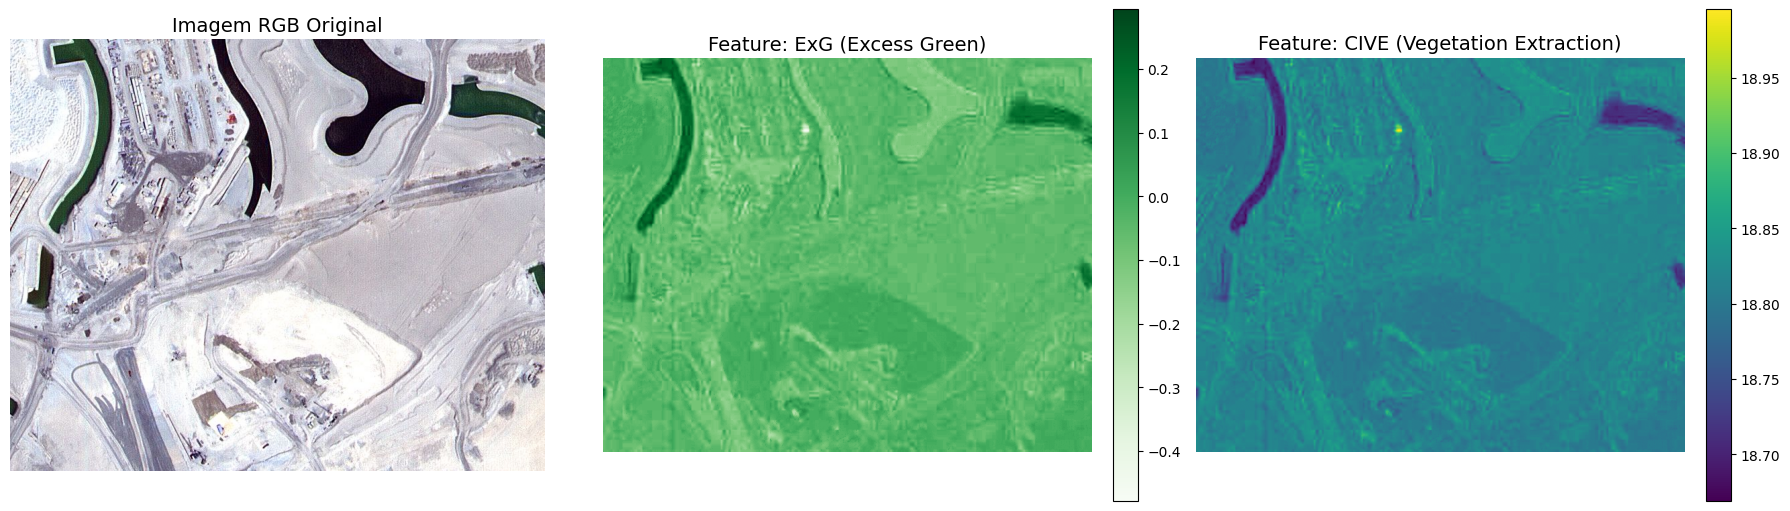

In [2]:
plt.figure(figsize=(18, 6))

# Plot 1: A Imagem RGB Original
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Imagem RGB Original", fontsize=14)
plt.axis('off')

# Plot 2: Canal ExG
plt.subplot(1, 3, 2)
# Usamos o colormap 'Greens' para destacar os valores altos
plt.imshow(exg, cmap='Greens')
plt.title("Feature: ExG (Excess Green)", fontsize=14)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

# Plot 3: Canal CIVE
plt.subplot(1, 3, 3)
# Usamos o colormap 'viridis' para observar a separação matemática
plt.imshow(cive, cmap='viridis')
plt.title("Feature: CIVE (Vegetation Extraction)", fontsize=14)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.tight_layout()
plt.show()